# Christensen CIK Analysis

Analyses 1-2: does the annotator's C/I labeling track the dilemmas' ground-truth classification?

Uses `christensen_event_level_df.csv` (built by `christensen_df_maker.ipynb`).

In [1]:
from pathlib import Path
import json
import ast
import pandas as pd
import numpy as np
import sys
from IPython.display import display, HTML


In [2]:
src_path = Path().resolve() / "../../src"
sys.path.append(str(src_path))
project_root = src_path.resolve().parent
sys.path.append(str(project_root))

# christensen_utility_funcs imports src.generic_analysis_utils, so project_root must already be
# on sys.path before either import happens
import src.generic_analysis_utils as generic_analysis_utils
import christensen_utility_funcs as christensen_funcs


In [3]:
%load_ext autoreload
%autoreload 2


## Load cached event-level dataframe

In [4]:
event_df = pd.read_csv("christensen_event_level_df.csv")
event_df["utility"] = event_df["utility"].apply(ast.literal_eval)
display(HTML(event_df.head().to_html()))


,SID,option,event,C,I,K,utility,deontic,scenario_title,evitability,personal_force,intentionality,beneficial_to
0,0,1,The injured person dies,+,-,+,"{'i': 0, '1 injured person at the exit': -100}",-37.0,burning_building,evitable,personal,means,self
1,0,1,The exit blockage is broken open,+,+,+,"{'i': 60, '1 injured person at the exit': 85}",-37.0,burning_building,evitable,personal,means,self
2,0,1,The five people behind me escape the burning building,+,+,+,"{'i': 8, '1 injured person at the exit': 8}",-37.0,burning_building,evitable,personal,means,self
3,1,1,The hallway is deprived of oxygen.,+,+,+,"{'i': -80, '1 injured person crawling through the hole at the exit': -85}",12.0,burning_building,evitable,impersonal,side_effect,self
4,1,1,The fire in the hallway is extinguished.,+,+,+,"{'i': 35, '1 injured person crawling through the hole at the exit': 75}",12.0,burning_building,evitable,impersonal,side_effect,self


## Analysis 1 -- Does I+ (intention) track the ground-truth Intentionality label?

**Question:** Does the annotator assign more I+ to scenarios labeled Instrumental (`means`) as opposed to Accidental (`side_effect`)?

Restricted to harmful events only (negative utility to the patient/bystander), since intentionality is only meaningful for events that actually cause harm.

**Promising observation:** high %I+ for `means`, low for `side_effect`.

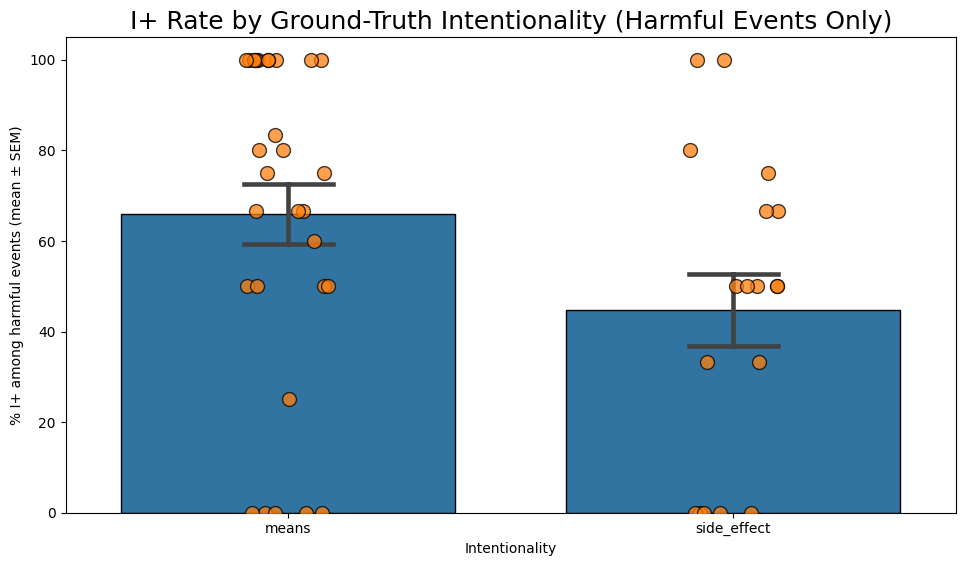

In [5]:
pct_I_plus_harm_only = christensen_funcs.pct_plus_per_scenario(event_df, "I", restrict_to_harm_events=True)

intentionality_df = event_df[["SID", "intentionality"]].drop_duplicates().set_index("SID")
intentionality_df["pct_I_plus_harm_only"] = pct_I_plus_harm_only
intentionality_df = intentionality_df.reset_index()

generic_analysis_utils.plot_bar_strip(
    intentionality_df,
    x="intentionality",
    y="pct_I_plus_harm_only",
    ylabel="% I+ among harmful events (mean ± SEM)",
    title="I+ Rate by Ground-Truth Intentionality (Harmful Events Only)",
)


In [6]:
from scipy.stats import ttest_ind

means_vals = intentionality_df.loc[intentionality_df["intentionality"] == "means", "pct_I_plus_harm_only"].dropna()
side_effect_vals = intentionality_df.loc[intentionality_df["intentionality"] == "side_effect", "pct_I_plus_harm_only"].dropna()
t_stat, p_val = ttest_ind(means_vals, side_effect_vals)
print(f"means (n={len(means_vals)}) vs side_effect (n={len(side_effect_vals)}): t={t_stat:.3f}, p={p_val:.4f}")


means (n=30) vs side_effect (n=18): t=2.009, p=0.0504


## Analysis 2 -- Does C+ (causality) track Evitability?

**Question:** Does the annotator assign less C+ to scenarios when the outcome was inevitable as opposed to evitable?

**Promising observation:** lower %C+ for `inevitable` than `evitable`.

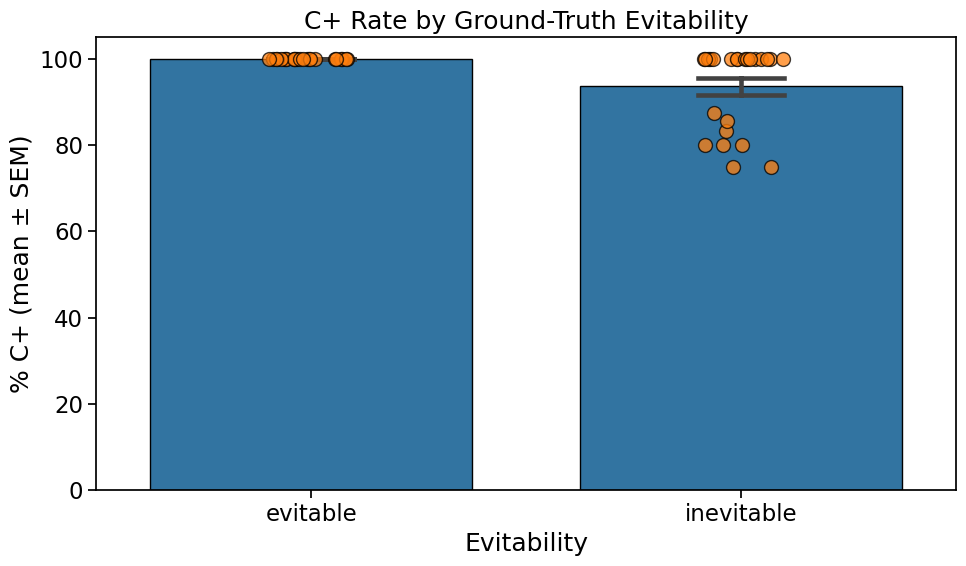

In [7]:
pct_C_plus = christensen_funcs.pct_plus_per_scenario(event_df, "C")

evitability_df = event_df[["SID", "evitability"]].drop_duplicates().set_index("SID")
evitability_df["pct_C_plus"] = pct_C_plus
evitability_df = evitability_df.reset_index()

generic_analysis_utils.plot_bar_strip(
    evitability_df,
    x="evitability",
    y="pct_C_plus",
    ylabel="% C+ (mean ± SEM)",
    title="C+ Rate by Ground-Truth Evitability",
)


In [8]:
from scipy.stats import ttest_ind

evitable_vals = evitability_df.loc[evitability_df["evitability"] == "evitable", "pct_C_plus"].dropna()
inevitable_vals = evitability_df.loc[evitability_df["evitability"] == "inevitable", "pct_C_plus"].dropna()
t_stat, p_val = ttest_ind(evitable_vals, inevitable_vals)
print(f"evitable (n={len(evitable_vals)}) vs inevitable (n={len(inevitable_vals)}): t={t_stat:.3f}, p={p_val:.4f}")


evitable (n=24) vs inevitable (n=24): t=3.273, p=0.0020


/home/bhatto/miniconda3/envs/graphextractconda/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
